# Atividade 3 -- Tópicos para Computação 1 -- 2026.1

- Escola Superior de Tecnologia
- Profa. Dra. Elloá B. Guedes (ebgcosta@uea.edu.br)
- www.elloaguedes.com
- github.com/elloa
- Data: 19 de março de 2026

## Descrição

A atividade consiste em construir uma rede neural convolucional para classificar o _Stanford Dogs Dataset_, um dataset com imagens de 120 raças de cachorro de todo o mundo e mais de 20 mil imagens para treino e teste.

## Material de Referência para Estudo

- http://vision.stanford.edu/aditya86/ImageNetDogs/


## Prazos importantes

- Data de entrega: 23/03/2026
- Modo de entrega: Google Classroom

## Equipe

- Adriana Raffaella
- Cristiano Peniche
- Henrique Furtado
- Paulo Andrade

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import os
import shutil
import csv
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from torchsummary import summary
from prettytable import PrettyTable
from sklearn.metrics import classification_report, confusion_matrix

# Obtenção do dataset

- A tarefa a ser considerada é uma tarefa de classificação multiclasse
- A documentação oficial do dataset pode ser obtida aqui: http://vision.stanford.edu/aditya86/ImageNetDogs/
- Vamos usar essa versão do Kaggle em que as imagens e rótulos já estão organizados:
  https://www.kaggle.com/datasets/miljan/stanford-dogs-dataset-traintest
- Instale a API do Kaggle e faça o download do dataset usando Python
- Organize o nome das classes, retire o identificador "n[id]" do início das pastas

In [2]:
# Preparando dirétorio
BASE_DIR = os.getcwd()
print(f"Base Directory: {BASE_DIR}")
local_path = os.path.join(BASE_DIR, "dataset_dogs")
print(f"Local Path: {local_path}")
base_path = os.path.join(local_path, "cropped")
print(f"Base Path: {base_path}")    
train_dir = os.path.join(base_path, "train")
print(f"Train Directory: {train_dir}")
test_dir = os.path.join(base_path, "test")
print(f"Test Directory: {test_dir}")

Base Directory: c:\Users\paulo\Downloads\CNN
Local Path: c:\Users\paulo\Downloads\CNN\dataset_dogs
Base Path: c:\Users\paulo\Downloads\CNN\dataset_dogs\cropped
Train Directory: c:\Users\paulo\Downloads\CNN\dataset_dogs\cropped\train
Test Directory: c:\Users\paulo\Downloads\CNN\dataset_dogs\cropped\test


In [3]:
# Baixando dataset
if not os.path.exists(local_path):
    print("Baixando dataset...")
    try:
        downloaded_path = kagglehub.dataset_download("miljan/stanford-dogs-dataset-traintest")
        print(f"Copiando arquivos para: {local_path}")
        shutil.copytree(downloaded_path, local_path)
    except Exception as e:
        print(f"Erro no download/cópia: {e}")

pasta_redundante = os.path.join(base_path, "cropped")
if os.path.exists(pasta_redundante):
    shutil.rmtree(pasta_redundante)

# Renomeando os arquivos
if os.path.exists(base_path):
    for subpasta in ['train', 'test']:
        path_alvo = os.path.join(base_path, subpasta)
        if os.path.exists(path_alvo):
            for folder_name in os.listdir(path_alvo):
                old_path = os.path.join(path_alvo, folder_name)
                if os.path.isdir(old_path) and '-' in folder_name:
                    new_name = folder_name.split('-', 1)[1]
                    new_path = os.path.join(path_alvo, new_name)
                    if not os.path.exists(new_path):
                        os.rename(old_path, new_path)

# Escolha do dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Baixando dataset...
Copiando arquivos para: c:\Users\paulo\Downloads\CNN\dataset_dogs
Usando dispositivo: cuda


# Transformações na Entrada, Image Handler e Data Loader

- As imagens precisam ser padronizadas, vamos usar as dimensões 224x224 e a normalização das cores
- Transformação das Imagens: https://docs.pytorch.org/vision/0.8/transforms.html
- Operações: Redimensionamento, Para Tensor e Normalização ([-1,1] com média 0.5 e desvio padrão de 0.5)
- Criar um ImageHandler para cada pasta (treino/teste):
  - https://docs.pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html#torchvision.datasets.ImageFolder
- Para o treinamento: criar um Data loader com tamanho de lote igual a 32 e randomização
- https://docs.pytorch.org/docs/stable/data.html
- Para o teste: criar um Data loader com lote de tamanho igual a 1 e sem randomização

In [7]:
# Variáveis estáticas
img_size = 224
batch_size_train = 32
batch_size_test = 1
num_epochs = 120
learning_rate = 1e-3
momentum_val = 0.9
num_classes = 120

In [9]:
dt_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_dataset = datasets.ImageFolder(root=train_dir, transform=dt_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=dt_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size_train, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size_test, shuffle=False, num_workers=0)

print(f"Número de classes: {len(train_dataset.classes)}")
print(f"Imagens de treino: {len(train_dataset)} | Lotes: {len(train_loader)}")
print(f"Imagens de teste: {len(test_dataset)} | Lotes: {len(test_loader)}")

Número de classes: 120
Imagens de treino: 12000 | Lotes: 375
Imagens de teste: 8580 | Lotes: 8580


## Entendendo o Image Handler (dataset.ImageFolder) DataLoader

- Responda ao que se pede:
    1. Qual o papel do ImageHandler nesse contexto?
    
    *Ele mapeia automaticamente a estrutura de pastas para as labels. Como cada raça está em uma subpasta, o ImageFolder atribui um número inteiro a cada raça e aplica a transformações apenas quando a imagem é requisitada.*

    2. E do DataLoader?

    *Ele gerencia a logística, pega o dataset e organiza a entrega das imagens em batches, gerencia a ordem e pode usar vários núcleos do processador para carregar mais rápido.*

    3. Por que o tamanho do batch não pode ser todo o conjunto de dados?
    
    *Pois carregar milhares de imagens de alta resolução ao mesmo tempo causaria um estouro de memória. Além disso, usar batches menores ajuda o modelo a expor mínimos locais.*

    4. Por que o DataLoader do treinamento precisa de aleatoriedade?
    
    *Para evitar que o modelo aprenda a ordem das imagens ou que fique tendêncioso caso os dados estejam agrupados por raça nas pastas. Assim, garante que cada lote seja uma amostra variada do problema.*

    5. Por que o DataLoader do teste deve ter batch igual a 1 e sem aleatoriedade?
    
    *O batch igual a 1 facilita a avaliação individual e a extração de métricas detalhadas. A ausência de aleatoriedade é útil para que os resultados sejam consistentes e sempre rodarmos o teste para validar o desempenho no final.*

## Construindo sua primeira CNN: AlexNet

- Construa, camada a camada, a CNN AlexNet, vencedora do ImageNet 2012
- Arquitetura da AlexNet é dada a seguir:
1. Conv 1: 96 filtros de tamanho $11 \times 11$, com um stride (passo) de 4.
2. Max Pool 1: Redução espacial com janelas de $3 \times 3$ e stride 2.
3. Conv 2: 256 filtros de $5 \times 5$ com padding para manter a dimensão.
4. Max Pool 2: Outra redução de $3 \times 3$ com stride 2.
5. Conv 3, 4 e 5: Camadas convolucionais puras (sem pooling entre elas) com 384, 384 e 256 filtros de $3 \times 3$, respectivamente.
6. Max Pool 3: Última redução antes das camadas densas.
7. Camada de adaptação para classificação: Adaptive Average Pooling Bidimensional 6x6
8. FC 6 e 7: Duas camadas densas com 4096 neurônios cada, utilizando Dropout de 0.5 para reduzir o overfitting.
9. FC 8 (Saída): Camada final com ativação Softmax. Ajuste a camada de saída para o número de classes do problema encontrado.

### Sumário do Modelo

- Apresente o sumário do modelo, indicando quantos parâmetros ele possui e quantos destes são treináveis.


### Links Úteis

- https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
- https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.pooling.MaxPool2d.html
- https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.activation.ReLU.html
- https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.pooling.AdaptiveAvgPool2d.html
- https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.dropout.Dropout.html





In [10]:
class AlexNet(nn.Module):
  def __init__(self, num_classes=120):
    super(AlexNet, self).__init__()

    self.features = nn.Sequential(
      nn.Conv2d(in_channels=3, out_channels=96, kernel_size=11, stride=4, padding=0),
      nn.ReLU(inplace=True),
      nn.MaxPool2d(kernel_size=3, stride=2),

      nn.Conv2d(in_channels=96, out_channels=256, kernel_size=5, padding=2),
      nn.ReLU(inplace=True),
      nn.MaxPool2d(kernel_size=3, stride=2),

      nn.Conv2d(in_channels=256, out_channels=384, kernel_size=3, padding=1),
      nn.ReLU(inplace=True),
      nn.Conv2d(in_channels=384, out_channels=384, kernel_size=3, padding=1),
      nn.ReLU(inplace=True),
      nn.Conv2d(in_channels=384, out_channels=256, kernel_size=3, padding=1),
      nn.ReLU(inplace=True),
      nn.MaxPool2d(kernel_size=3, stride=2),
    )

    self.avgpool = nn.AdaptiveAvgPool2d((6, 6))

    self.classifier = nn.Sequential(
      nn.Dropout(p=0.5),
      nn.Linear(256 * 6 * 6, 4096),
      nn.ReLU(inplace=True),

      nn.Dropout(p=0.5),
      nn.Linear(4096, 4096),
      nn.ReLU(inplace=True),

      nn.Linear(4096, num_classes),
      nn.Softmax(dim=1)
    )

  def forward(self, x):
    x = self.features(x)
    x = self.avgpool(x)
    x = torch.flatten(x, 1)
    x = self.classifier(x)
    return x

# Instanciando modelo
model = AlexNet(num_classes=num_classes).to(device)

In [11]:
# Sumário do modelo
summary(model=model, input_size=(3, img_size, img_size))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 96, 54, 54]          34,944
              ReLU-2           [-1, 96, 54, 54]               0
         MaxPool2d-3           [-1, 96, 26, 26]               0
            Conv2d-4          [-1, 256, 26, 26]         614,656
              ReLU-5          [-1, 256, 26, 26]               0
         MaxPool2d-6          [-1, 256, 12, 12]               0
            Conv2d-7          [-1, 384, 12, 12]         885,120
              ReLU-8          [-1, 384, 12, 12]               0
            Conv2d-9          [-1, 384, 12, 12]       1,327,488
             ReLU-10          [-1, 384, 12, 12]               0
           Conv2d-11          [-1, 256, 12, 12]         884,992
             ReLU-12          [-1, 256, 12, 12]               0
        MaxPool2d-13            [-1, 256, 5, 5]               0
AdaptiveAvgPool2d-14            [-1, 25

## Configuração do Treino

- 120 épocas
- Otimizador: Mini-batch SGD com Momentum (tal qual no paper original da AlexNet)
- Zere os gradientes do otimizador
- Lotes de 32
- Taxa de aprendizado: 10^(-3)
- Momentum: 0.9
- Função de perda: Entropia Cruzada Categórica
- Caso tenha disponibilidade, acelere o treino com GPU

### Monitorando o Treinamento

- Ao longo das épocas, armazene o loss e a acurácia no treino em um arquivo csv

#### Links Úteis

- https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html
- https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum_val)

log_file = os.path.join(BASE_DIR, 'training_history.csv')
with open(log_file, mode='w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['epoch', 'train_loss', 'train_acc'])

In [ ]:
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
print(f"\n Iniciando treino em: {gpu_name}")
    
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = 100 * correct / total

    print(f'Epoch [{epoch+1:03d}/{num_epochs}] - Loss: {epoch_loss:.4f} - Acc: {epoch_acc:.2f}%')

    with open(log_file, mode='a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([epoch + 1, epoch_loss, epoch_acc])


🚀 Iniciando treino em: NVIDIA GeForce RTX 3060 Ti
Epoch [001/120] - Loss: 4.7875 - Acc: 0.87%
Epoch [002/120] - Loss: 4.7875 - Acc: 0.92%
Epoch [003/120] - Loss: 4.7875 - Acc: 0.81%
Epoch [004/120] - Loss: 4.7875 - Acc: 0.85%
Epoch [005/120] - Loss: 4.7875 - Acc: 0.93%
Epoch [006/120] - Loss: 4.7875 - Acc: 0.86%
Epoch [007/120] - Loss: 4.7875 - Acc: 0.83%
Epoch [008/120] - Loss: 4.7875 - Acc: 0.82%
Epoch [009/120] - Loss: 4.7875 - Acc: 0.82%
Epoch [010/120] - Loss: 4.7875 - Acc: 0.91%
Epoch [011/120] - Loss: 4.7875 - Acc: 0.80%
Epoch [012/120] - Loss: 4.7875 - Acc: 0.88%
Epoch [013/120] - Loss: 4.7875 - Acc: 0.88%
Epoch [014/120] - Loss: 4.7875 - Acc: 0.78%
Epoch [015/120] - Loss: 4.7875 - Acc: 0.83%
Epoch [016/120] - Loss: 4.7875 - Acc: 0.93%
Epoch [017/120] - Loss: 4.7875 - Acc: 0.80%
Epoch [018/120] - Loss: 4.7875 - Acc: 0.82%
Epoch [019/120] - Loss: 4.7875 - Acc: 0.85%
Epoch [020/120] - Loss: 4.7875 - Acc: 0.83%
Epoch [021/120] - Loss: 4.7875 - Acc: 0.82%
Epoch [022/120] - Loss: 4

## Métricas do Treinamento

- Elabore um gráfico com a função de perda ao longo das épocas
- Elabore um gráfico com a acurácia do conjunto de treino ao longo das épocas
- Responda: O treino foi eficiente?

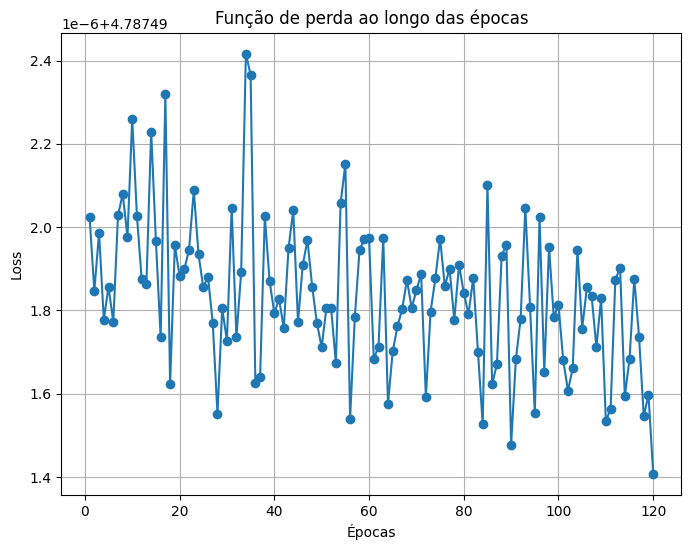

In [ ]:
df_training_history = pd.read_csv('training_history.csv')

plt.figure(figsize=(8,6))

plt.plot(df_training_history['epoch'], df_training_history['train_loss'], marker='o')
plt.title('Função de perda ao longo das épocas')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

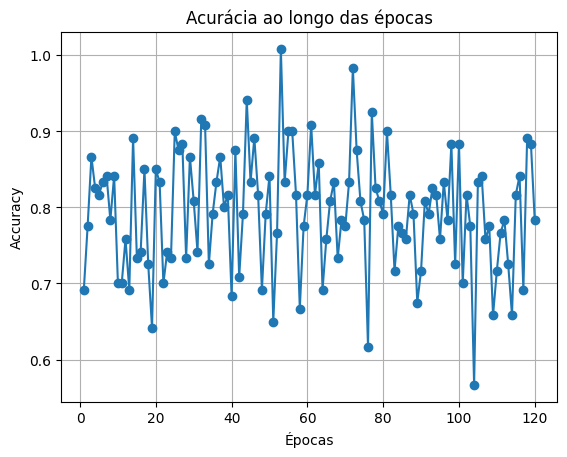

In [ ]:
plt.plot(df_training_history['epoch'], df_training_history['train_acc'], marker='o')
plt.title('Acurácia ao longo das épocas')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

### Persista o modelo

- Salvar o modelo com os pesos após o aprendizado é uma estratégia importante para posteriormente utilizá-lo para inferência ou para análises comparativas
- Nesta atividade, salve o modelo em disco e recupere-o para efetuar a avaliação no conjunto de testes

In [ ]:
#  Salvando modelo do AlexNet
torch.save(model.state_dict(), 'alexnet_dogs_final.pth')

## Avaliação do Modelo

- Faça as inferências do modelo para o conjunto de testes e cálcule as métricas para uma tarefa de classificação multiclasse
- Elabore uma matriz de confusão
- Escolha três exemplos aleatórios do conjunto de testes, exiba-as e mostre também as top-3 probabilidades de classificação

In [ ]:
y_true = []
y_pred = []

# Modelo em modo de avaliação
model.eval()

# Inferência do modelo
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        # Busca o maior tensor -> Saída é um logits
        _, predicted = torch.max(outputs, 1)

y_true.extend(labels.cpu().numpy())
y_pred.extend(predicted.cpu().numpy())

report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)

table_metrics = PrettyTable()
table_metrics.field_names = ['Classe', 'Precision', 'Recall', 'F1-Score', 'Support']

for classe, valores in report.items():

    if classe not in ['accuracy', 'macro avg', 'weighted avg']:
        table_metrics.add_row([
            classe,
            #round(valores['accuracy'], 3),
            round(valores['precision'], 3),
            round(valores['recall'], 3),
            round(valores['f1-score'], 3),
            round(valores['support'], 3),
        ])

print(f"\nAcurácia Global do Modelo: {round(report['accuracy'], 3)}")
print(table_metrics)


Acurácia Global do Modelo: 0.0
+--------+-----------+--------+----------+---------+
| Classe | Precision | Recall | F1-Score | Support |
+--------+-----------+--------+----------+---------+
|   86   |    0.0    |  0.0   |   0.0    |   0.0   |
|  119   |    0.0    |  0.0   |   0.0    |   1.0   |
+--------+-----------+--------+----------+---------+


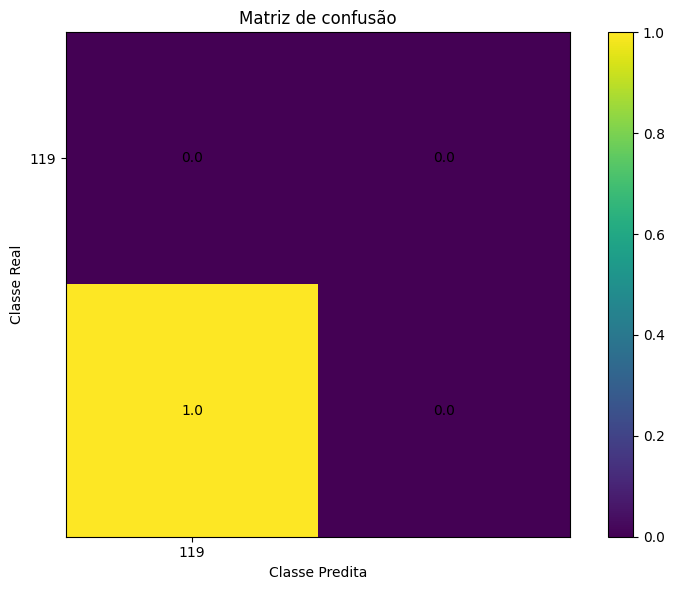

In [ ]:
cm = confusion_matrix(y_true, y_pred, normalize='true')

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest')
plt.title('Matriz de confusão')
plt.colorbar()

classes = np.unique(y_true)
tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
            ha='center',
            va='center')
        
plt.tight_layout()
plt.show()

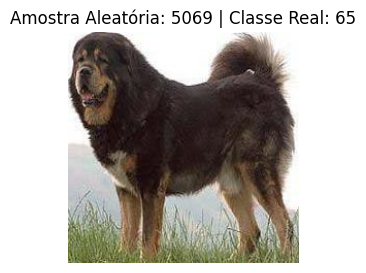

+------+----------------+---------------+
| Rank | Classe Predita | Probabilidade |
+------+----------------+---------------+
|  1   |       86       |     0.83%     |
|  2   |       78       |     0.83%     |
|  3   |       68       |     0.83%     |
+------+----------------+---------------+




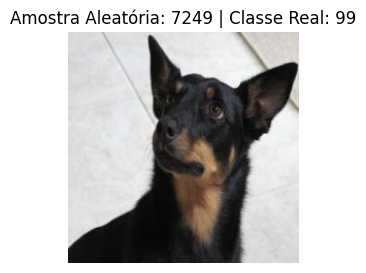

+------+----------------+---------------+
| Rank | Classe Predita | Probabilidade |
+------+----------------+---------------+
|  1   |       86       |     0.83%     |
|  2   |       78       |     0.83%     |
|  3   |       68       |     0.83%     |
+------+----------------+---------------+




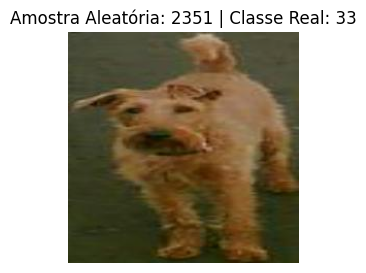

+------+----------------+---------------+
| Rank | Classe Predita | Probabilidade |
+------+----------------+---------------+
|  1   |       86       |     0.83%     |
|  2   |       68       |     0.83%     |
|  3   |       78       |     0.83%     |
+------+----------------+---------------+




In [ ]:
# Quantidade total de imagens no conjunto de teste
total_images = len(test_dataset)

# Escolhe 3 índices aleatórios do dataset inteiro
indices = random.sample(range(total_images), 3)

for idx in indices:
    # Pega a imagem e a label direto do dataset usando o índice
    image, label = test_dataset[idx]
    
    # 1. Preparar a imagem para exibição no matplotlib (Desnormalizar)
    img_display = image.numpy().transpose((1, 2, 0)) # Muda a ordem dos canais
    img_display = img_display * 0.5 + 0.5            # Desfaz a normalização [-1, 1] para [0, 1]
    img_display = np.clip(img_display, 0, 1)         # Garante que as cores fiquem no limite certo
    
    # 2. Passar a imagem no modelo para inferência
    # O dataset retorna (C, H, W), precisamos adicionar o batch pra ficar (1, C, H, W)
    img_tensor = image.unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)
        top_probs, top_classes = torch.topk(probs, 3)
    
    # 3. Exibir a imagem do cachorro
    plt.figure(figsize=(3, 3))
    plt.imshow(img_display)
    plt.title(f"Amostra Aleatória: {idx} | Classe Real: {label}")
    plt.axis('off')
    plt.show()

    # 4. Exibir a tabela com o Top-3
    table_top3 = PrettyTable()
    table_top3.field_names = ['Rank', 'Classe Predita', 'Probabilidade']

    for i in range(3):
        table_top3.add_row([
            i+1,
            int(top_classes[0][i]),
            f"{float(top_probs[0][i]) * 100:.2f}%" # Formatando em porcentagem
        ])

    print(table_top3)
    print("\n" + "="*40 + "\n")

## Parecer Avaliativo

- Elabore um parecer sobre o desempenho do modelo, elencando vantagens e limitações
- Faça a sugestão de três estratégias a serem incorporadas no modelo ou em seu treinamento para que haja melhoria de desempenho